# 02 - Tokenization, Vocabulary, and Split-Aware Sequence Cache

Build event-token sequences and cache them by file with explicit split labels (`train`, `val`, `test`) to prevent leakage.


In [15]:
# Optional for Colab
# !pip install -q pandas numpy matplotlib seaborn pretty_midi scikit-learn


In [25]:
from pathlib import Path
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pretty_midi
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_ROOT = Path('/Users/ryan/Documents/CS372/RScs372_finalproject/data/raw/maestro-v3.0.0')
MIDI_BASE_DIR = DATA_ROOT
PROJECT_OUTPUT_DIR = Path('/Users/ryan/Documents/CS372/RScs372_finalproject/data/project_outputs')
CACHE_DIR = PROJECT_OUTPUT_DIR / 'cache'
TABLE_DIR = PROJECT_OUTPUT_DIR / 'tables'
FIG_DIR = PROJECT_OUTPUT_DIR / 'figures'

meta_proc = pd.read_csv(CACHE_DIR / 'meta_processed.csv')
cfg = pd.read_csv(CACHE_DIR / 'preprocess_config.csv').iloc[0].to_dict()
SEED = int(cfg['seed'])
TIME_BIN_SEC = float(cfg['time_bin_sec'])
random.seed(SEED)
np.random.seed(SEED)


In [32]:
MAX_FILES_PER_SPLIT = 1000
SEQ_LEN = 256
STRIDE = 128

# Keep split integrity from metadata and sample within each split for runtime control.
parts = []
for s in ['train','val','test']:
    sub = meta_proc[meta_proc['split_norm'] == s].copy()
    if len(sub) > MAX_FILES_PER_SPLIT:
        sub = sub.sample(MAX_FILES_PER_SPLIT, random_state=SEED)
    parts.append(sub)
work_df = pd.concat(parts, ignore_index=True)

print('Rows by split used:')
print(work_df['split_norm'].value_counts())


Rows by split used:
split_norm
train    929
test     177
val      135
Name: count, dtype: int64


In [33]:
def qtime(x, bin_sec):
    return np.round(x / bin_sec) * bin_sec


def notes_from_midi(midi_path):
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    notes = []
    for inst in pm.instruments:
        for n in inst.notes:
            notes.append((float(n.start), float(n.end), int(n.pitch), int(n.velocity)))
    notes.sort(key=lambda x: x[0])
    return notes


def notes_to_events(notes, quantize=False, time_bin=0.01):
    events = []
    raw_events = []
    for s, e, p, _v in notes:
        if quantize:
            s = float(qtime(s, time_bin))
            e = float(max(qtime(e, time_bin), s + time_bin))
        raw_events.append((s, f'NOTE_ON_{p}'))
        raw_events.append((e, f'NOTE_OFF_{p}'))

    raw_events.sort(key=lambda x: x[0])
    prev_t = 0.0
    for t, ev in raw_events:
        dt = max(0.0, t - prev_t)
        if dt > 0:
            if quantize:
                step = int(max(1, round(dt / time_bin)))
                events.append(f'TIME_SHIFT_{step}')
            else:
                ms = int(max(1, round(dt * 1000)))
                events.append(f'TIME_SHIFT_MS_{ms}')
        events.append(ev)
        prev_t = t
    return events


def build_windows(ids, seq_len=128, stride=64):
    X, y = [], []
    for i in range(0, max(0, len(ids) - seq_len), stride):
        j = i + seq_len
        if j < len(ids):
            X.append(ids[i:j])
            y.append(ids[j])
    return X, y


In [35]:
# Build per-file sequences with split labels for anti-leakage downstream.
records = []
for _, r in work_df.iterrows():
    midi_rel = str(r['midi_filename'])
    p = MIDI_BASE_DIR / midi_rel
    if not p.exists():
        continue
    try:
        notes = notes_from_midi(p)
        if len(notes) < 10:
            continue
        records.append({
            'midi_filename': midi_rel,
            'split_norm': str(r['split_norm']),
            #'raw_tokens': notes_to_events(notes, quantize=False, time_bin=TIME_BIN_SEC),
            'quant_tokens': notes_to_events(notes, quantize=True, time_bin=TIME_BIN_SEC),
        })
    except Exception:
        continue

seq_df = pd.DataFrame(records)
print('Tokenized files:', len(seq_df))
print(seq_df['split_norm'].value_counts())


Tokenized files: 1241
split_norm
train    929
test     177
val      135
Name: count, dtype: int64


In [37]:
# Shared vocabulary across both raw and quantized token sets.
all_tokens = []
# for toks in seq_df['raw_tokens']:
#     all_tokens.extend(toks)
for toks in seq_df['quant_tokens']:
    all_tokens.extend(toks)

vocab = sorted(set(all_tokens))
tok2id = {t:i for i,t in enumerate(vocab)}
id2tok = {i:t for t,i in tok2id.items()}
print('Vocab size:', len(vocab))


Vocab size: 1059


In [39]:
# Convert each file's token sequence to ids/windows, preserving split by file.
file_sequences = []
for _, r in seq_df.iterrows():
    # raw_ids = [tok2id[t] for t in r['raw_tokens'] if t in tok2id]
    quant_ids = [tok2id[t] for t in r['quant_tokens'] if t in tok2id]

    # raw_X, raw_y = build_windows(raw_ids, seq_len=SEQ_LEN, stride=STRIDE)
    q_X, q_y = build_windows(quant_ids, seq_len=SEQ_LEN, stride=STRIDE)

    file_sequences.append({
        'midi_filename': r['midi_filename'],
        'split_norm': r['split_norm'],
        # 'raw_X': raw_X,
        # 'raw_y': raw_y,
        'quant_X': q_X,
        'quant_y': q_y,
    })

# Flattened convenience views (still split-safe because built from file-labeled records).
def flatten_by_split(file_records, split_name, x_key, y_key):
    X, y = [], []
    for rec in file_records:
        if rec['split_norm'] == split_name:
            X.extend(rec[x_key])
            y.extend(rec[y_key])
    return X, y

# raw_train_X, raw_train_y = flatten_by_split(file_sequences, 'train', 'raw_X', 'raw_y')
# raw_val_X, raw_val_y = flatten_by_split(file_sequences, 'val', 'raw_X', 'raw_y')
# raw_test_X, raw_test_y = flatten_by_split(file_sequences, 'test', 'raw_X', 'raw_y')
q_train_X, q_train_y = flatten_by_split(file_sequences, 'train', 'quant_X', 'quant_y')
q_val_X, q_val_y = flatten_by_split(file_sequences, 'val', 'quant_X', 'quant_y')
q_test_X, q_test_y = flatten_by_split(file_sequences, 'test', 'quant_X', 'quant_y')

# print('Raw windows train/val/test:', len(raw_train_X), len(raw_val_X), len(raw_test_X))
print('Quant windows train/val/test:', len(q_train_X), len(q_val_X), len(q_test_X))


Quant windows train/val/test: 142712 16787 20655


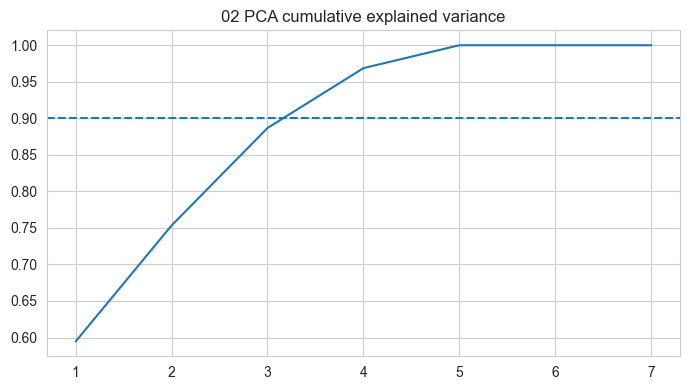

PCA components @90%: 4


In [40]:
# Feature engineering + PCA evidence (based on quantized token sequences).
def seq_features(tokens):
    n = len(tokens)
    n_time = sum(1 for t in tokens if t.startswith('TIME_SHIFT'))
    n_on = sum(1 for t in tokens if t.startswith('NOTE_ON_'))
    n_off = sum(1 for t in tokens if t.startswith('NOTE_OFF_'))
    pitches = [int(t.split('_')[-1]) for t in tokens if t.startswith('NOTE_ON_')]
    return {
        'n_tokens': n,
        'time_ratio': n_time / max(n, 1),
        'on_ratio': n_on / max(n, 1),
        'off_ratio': n_off / max(n, 1),
        'pitch_mean': float(np.mean(pitches)) if pitches else np.nan,
        'pitch_std': float(np.std(pitches)) if pitches else np.nan,
        'pitch_range': float((max(pitches) - min(pitches)) if pitches else np.nan),
    }

feature_df = pd.DataFrame([seq_features(t) for t in seq_df['quant_tokens']])
X = SimpleImputer(strategy='median').fit_transform(feature_df)
X = StandardScaler().fit_transform(X)
X_sel = VarianceThreshold(1e-8).fit_transform(X)
pca = PCA(random_state=SEED).fit(X_sel)
cum = np.cumsum(pca.explained_variance_ratio_)
k90 = int(np.searchsorted(cum, 0.9) + 1)

plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(cum)+1), cum)
plt.axhline(0.9, linestyle='--')
plt.title('02 PCA cumulative explained variance')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_pca_cumulative_variance.png', dpi=160)
plt.show()

print('PCA components @90%:', k90)


In [41]:
# Save split-aware cache for downstream notebooks.
cache_obj = {
    'seq_len': SEQ_LEN,
    'stride': STRIDE,
    'vocab': vocab,
    'tok2id': tok2id,
    'id2tok': id2tok,
    'file_sequences': file_sequences,
    'split_windows': {
        # 'raw': {
        #     'train_X': raw_train_X, 'train_y': raw_train_y,
        #     'val_X': raw_val_X, 'val_y': raw_val_y,
        #     'test_X': raw_test_X, 'test_y': raw_test_y,
        # },
        'quant': {
            'train_X': q_train_X, 'train_y': q_train_y,
            'val_X': q_val_X, 'val_y': q_val_y,
            'test_X': q_test_X, 'test_y': q_test_y,
        }
    }
}

with open(CACHE_DIR / 'sequence_cache_256seq.json', 'w') as f:
    json.dump(cache_obj, f)

# feature_df.to_csv(TABLE_DIR / '02_sequence_features.csv', index=False)
# pd.DataFrame([{'stage':'selected_features','n':X_sel.shape[1]},{'stage':'pca_k90','n':k90}]).to_csv(TABLE_DIR / '02_feature_selection_summary.csv', index=False)
# pd.DataFrame([
#     {'representation':'raw_time_tokens','n_windows':len(raw_train_X)+len(raw_val_X)+len(raw_test_X)},
#     {'representation':'quantized_tokens','n_windows':len(q_train_X)+len(q_val_X)+len(q_test_X)}
# ]).to_csv(TABLE_DIR / '02_representation_comparison.csv', index=False)

print('Saved split-aware sequence cache and notebook 02 outputs.')


Saved split-aware sequence cache and notebook 02 outputs.


In [24]:
# Rebuild + save an ablation-ready cache that includes per-file quant_ids for notebook 06.
required_vars = ['seq_df', 'tok2id', 'build_windows', 'SEQ_LEN', 'STRIDE', 'CACHE_DIR', 'vocab', 'id2tok']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}. Run earlier notebook 02 cells first."
    )

file_sequences_with_ids = []
for _, r in seq_df.iterrows():
    raw_ids = [tok2id[t] for t in r['raw_tokens'] if t in tok2id]
    quant_ids = [tok2id[t] for t in r['quant_tokens'] if t in tok2id]

    raw_X, raw_y = build_windows(raw_ids, seq_len=SEQ_LEN, stride=STRIDE)
    q_X, q_y = build_windows(quant_ids, seq_len=SEQ_LEN, stride=STRIDE)

    file_sequences_with_ids.append({
        'midi_filename': r['midi_filename'],
        'split_norm': r['split_norm'],
        'raw_ids': raw_ids,
        'quant_ids': quant_ids,
        # Keep legacy keys so older notebooks/scripts still work.
        'raw_X': raw_X,
        'raw_y': raw_y,
        'quant_X': q_X,
        'quant_y': q_y,
    })

raw_train_X2, raw_train_y2 = flatten_by_split(file_sequences_with_ids, 'train', 'raw_X', 'raw_y')
raw_val_X2, raw_val_y2 = flatten_by_split(file_sequences_with_ids, 'val', 'raw_X', 'raw_y')
raw_test_X2, raw_test_y2 = flatten_by_split(file_sequences_with_ids, 'test', 'raw_X', 'raw_y')
q_train_X2, q_train_y2 = flatten_by_split(file_sequences_with_ids, 'train', 'quant_X', 'quant_y')
q_val_X2, q_val_y2 = flatten_by_split(file_sequences_with_ids, 'val', 'quant_X', 'quant_y')
q_test_X2, q_test_y2 = flatten_by_split(file_sequences_with_ids, 'test', 'quant_X', 'quant_y')

cache_obj_with_quant_ids = {
    'seq_len': SEQ_LEN,
    'stride': STRIDE,
    'vocab': vocab,
    'tok2id': tok2id,
    'id2tok': id2tok,
    'file_sequences': file_sequences_with_ids,
    'split_windows': {
        'raw': {
            'train_X': raw_train_X2, 'train_y': raw_train_y2,
            'val_X': raw_val_X2, 'val_y': raw_val_y2,
            'test_X': raw_test_X2, 'test_y': raw_test_y2,
        },
        'quant': {
            'train_X': q_train_X2, 'train_y': q_train_y2,
            'val_X': q_val_X2, 'val_y': q_val_y2,
            'test_X': q_test_X2, 'test_y': q_test_y2,
        }
    }
}

# Save only the quant_ids cache variant (do not overwrite existing default cache).
quant_ids_cache_path = CACHE_DIR / 'sequence_cache_with_quant_ids.json'
with open(quant_ids_cache_path, 'w') as f:
    json.dump(cache_obj_with_quant_ids, f)

print('Saved ablation-ready cache with per-file quant_ids:')
print(' -', quant_ids_cache_path)
print('Example file_sequence keys:', list(file_sequences_with_ids[0].keys()))

Saved ablation-ready cache with per-file quant_ids:
 - /Users/ryan/Documents/CS372/RScs372_finalproject/data/project_outputs/cache/sequence_cache_with_quant_ids.json
Example file_sequence keys: ['midi_filename', 'split_norm', 'raw_ids', 'quant_ids', 'raw_X', 'raw_y', 'quant_X', 'quant_y']
